In [20]:
import pandas as pd
import numpy as np

print("✓ Libraries imported")

✓ Libraries imported


## Step 1: Load Selected Enzymes

In [15]:
# Load Site I and Site II enzymes from enzyme_selection_analysis.ipynb
print("Loading selected enzymes...")

df_site_i = pd.read_csv('./output/selected_site_i_enzymes.csv')
df_site_ii = pd.read_csv('./output/selected_site_ii_enzymes.csv')

print(f"✓ Site I enzymes: {len(df_site_i)}")
print(f"✓ Site II enzymes: {len(df_site_ii)}")

# Get unique enzymes (Site II is subset of Site I)
site_i_enzymes = set(df_site_i['enzyme'].tolist())
site_ii_enzymes = set(df_site_ii['enzyme'].tolist())

# All unique enzymes from both sites
all_enzymes = sorted(site_i_enzymes | site_ii_enzymes)

print(f"\n✓ Total unique enzymes: {len(all_enzymes)}")
print(f"  - Site I only: {len(site_i_enzymes - site_ii_enzymes)}")
print(f"  - Site II (also in Site I): {len(site_ii_enzymes)}")
print(f"  - Verification: Site II ⊂ Site I: {site_ii_enzymes.issubset(site_i_enzymes)}")

Loading selected enzymes...
✓ Site I enzymes: 47
✓ Site II enzymes: 30

✓ Total unique enzymes: 47
  - Site I only: 17
  - Site II (also in Site I): 30
  - Verification: Site II ⊂ Site I: True


## Step 2: Load Plasmid Compatibility Data

In [16]:
# Load plasmid compatibility matrix
print("Loading plasmid compatibility data...")

df_plasmid_check = pd.read_csv('./utils/output/plasmid_digest_check.csv', index_col=0)

print(f"✓ Plasmid compatibility data: {df_plasmid_check.shape}")
print(f"  - Enzymes in database: {len(df_plasmid_check)}")
print(f"  - Plasmids: {list(df_plasmid_check.columns)}")

# Get plasmid names
plasmid_names = df_plasmid_check.columns.tolist()

Loading plasmid compatibility data...
✓ Plasmid compatibility data: (965, 8)
  - Enzymes in database: 965
  - Plasmids: ['pGEX-4T-1', 'pMAL-c5X', 'pET-21a(+)', 'pET-28a(+)', 'pET-28a(+)_start_codon', 'pCold_I', 'pUC18', 'pQE-3']


## Step 3: Build RE-Plasmid Compatibility DataFrame

In [17]:
print("Building RE-Plasmid compatibility dataframe...")

# Create list to store data
data = []

for enzyme in all_enzymes:
    # Get enzyme info from Site I or Site II data
    if enzyme in df_site_i['enzyme'].values:
        enzyme_info = df_site_i[df_site_i['enzyme'] == enzyme].iloc[0]
    elif enzyme in df_site_ii['enzyme'].values:
        enzyme_info = df_site_ii[df_site_ii['enzyme'] == enzyme].iloc[0]
    else:
        print(f"Warning: {enzyme} not found in Site I or II data")
        continue
    
    # Create row with enzyme info
    row = {
        'enzyme': enzyme,
        'ovhg': enzyme_info['ovhg'],
        'site': 'Site II' if enzyme in site_ii_enzymes else 'Site I only'
    }
    
    # Add plasmid compatibility for each plasmid
    for plasmid in plasmid_names:
        if enzyme in df_plasmid_check.index:
            row[plasmid] = df_plasmid_check.loc[enzyme, plasmid]
        else:
            row[plasmid] = False  # Not in database = not compatible
    
    data.append(row)

# Create DataFrame
df_re_plasmid = pd.DataFrame(data)

print(f"\n✓ Generated dataframe: {df_re_plasmid.shape}")
print(f"  - Enzymes: {len(df_re_plasmid)}")
print(f"  - Columns: {list(df_re_plasmid.columns)}")

# Display sample
print("\nSample rows:")
display(df_re_plasmid.head(10))

Building RE-Plasmid compatibility dataframe...

✓ Generated dataframe: (47, 11)
  - Enzymes: 47
  - Columns: ['enzyme', 'ovhg', 'site', 'pGEX-4T-1', 'pMAL-c5X', 'pET-21a(+)', 'pET-28a(+)', 'pET-28a(+)_start_codon', 'pCold_I', 'pUC18', 'pQE-3']

Sample rows:


,enzyme,ovhg,site,pGEX-4T-1,pMAL-c5X,pET-21a(+),pET-28a(+),pET-28a(+)_start_codon,pCold_I,pUC18,pQE-3
0,AatII,4,Site I only,False,True,True,True,True,True,False,False
1,AciI,-2,Site I only,False,False,False,False,False,False,False,False
2,AclI,-2,Site I only,False,False,False,False,False,False,False,False
3,AflII,-4,Site II,True,True,True,True,True,True,True,True
4,AgeI,-4,Site II,True,True,True,True,True,True,True,True
5,ApaI,4,Site I only,False,False,False,False,False,False,True,True
6,ApaLI,-4,Site II,False,False,False,False,False,False,False,False
7,AscI,-4,Site II,True,True,True,True,True,True,True,True
8,AvrII,-4,Site II,True,True,True,True,True,True,True,True
9,BclI,-4,Site II,False,False,False,False,False,False,True,True


## Step 4: Summary Statistics

In [18]:
print("="*80)
print("SUMMARY STATISTICS")
print("="*80)

# Enzyme counts by site
print("\n1. Enzyme counts by site:")
print(df_re_plasmid['site'].value_counts())

# Overhang distribution
print("\n2. Overhang distribution:")
print(df_re_plasmid['ovhg'].value_counts().sort_index())

# Compatibility by plasmid
print("\n3. Enzyme compatibility by plasmid:")
for plasmid in plasmid_names:
    compatible_count = df_re_plasmid[plasmid].sum()
    percentage = compatible_count / len(df_re_plasmid) * 100
    print(f"  {plasmid:25s}: {compatible_count:2d}/{len(df_re_plasmid)} ({percentage:5.1f}%)")

# Enzymes compatible with all plasmids
all_plasmid_compatible = df_re_plasmid[df_re_plasmid[plasmid_names].all(axis=1)]
print(f"\n4. Enzymes compatible with ALL plasmids: {len(all_plasmid_compatible)}")
if len(all_plasmid_compatible) > 0:
    print("  Enzymes:", sorted(all_plasmid_compatible['enzyme'].tolist()))

# Enzymes compatible with NO plasmids
no_plasmid_compatible = df_re_plasmid[~df_re_plasmid[plasmid_names].any(axis=1)]
print(f"\n5. Enzymes compatible with NO plasmids: {len(no_plasmid_compatible)}")
if len(no_plasmid_compatible) > 0:
    print("  Enzymes:", sorted(no_plasmid_compatible['enzyme'].tolist()))

SUMMARY STATISTICS

1. Enzyme counts by site:
site
Site II        30
Site I only    17
Name: count, dtype: int64

2. Overhang distribution:
ovhg
-4    26
-2    10
 2     4
 4     7
Name: count, dtype: int64

3. Enzyme compatibility by plasmid:
  pGEX-4T-1                : 25/47 ( 53.2%)
  pMAL-c5X                 : 24/47 ( 51.1%)
  pET-21a(+)               : 24/47 ( 51.1%)
  pET-28a(+)               : 20/47 ( 42.6%)
  pET-28a(+)_start_codon   : 23/47 ( 48.9%)
  pCold_I                  : 26/47 ( 55.3%)
  pUC18                    : 31/47 ( 66.0%)
  pQE-3                    : 26/47 ( 55.3%)

4. Enzymes compatible with ALL plasmids: 13
  Enzymes: ['AflII', 'AgeI', 'AscI', 'AvrII', 'BsrGI', 'FseI', 'HindIII', 'KpnI', 'NotI', 'PacI', 'SacII', 'SalI', 'SpeI']

5. Enzymes compatible with NO plasmids: 12
  Enzymes: ['AciI', 'AclI', 'ApaLI', 'BseYI', 'BspHI', 'HhaI', 'HpaII', 'MboI', 'MseI', 'NlaIII', 'PvuI', 'TaqI']


## Step 4.5: Generate Heatmap Visualization


Generating heatmap...
✓ Heatmap saved to: ./output/re_plasmid_compatibility_heatmap.pdf
✓ Heatmap saved to: ./output/re_plasmid_compatibility_heatmap.png


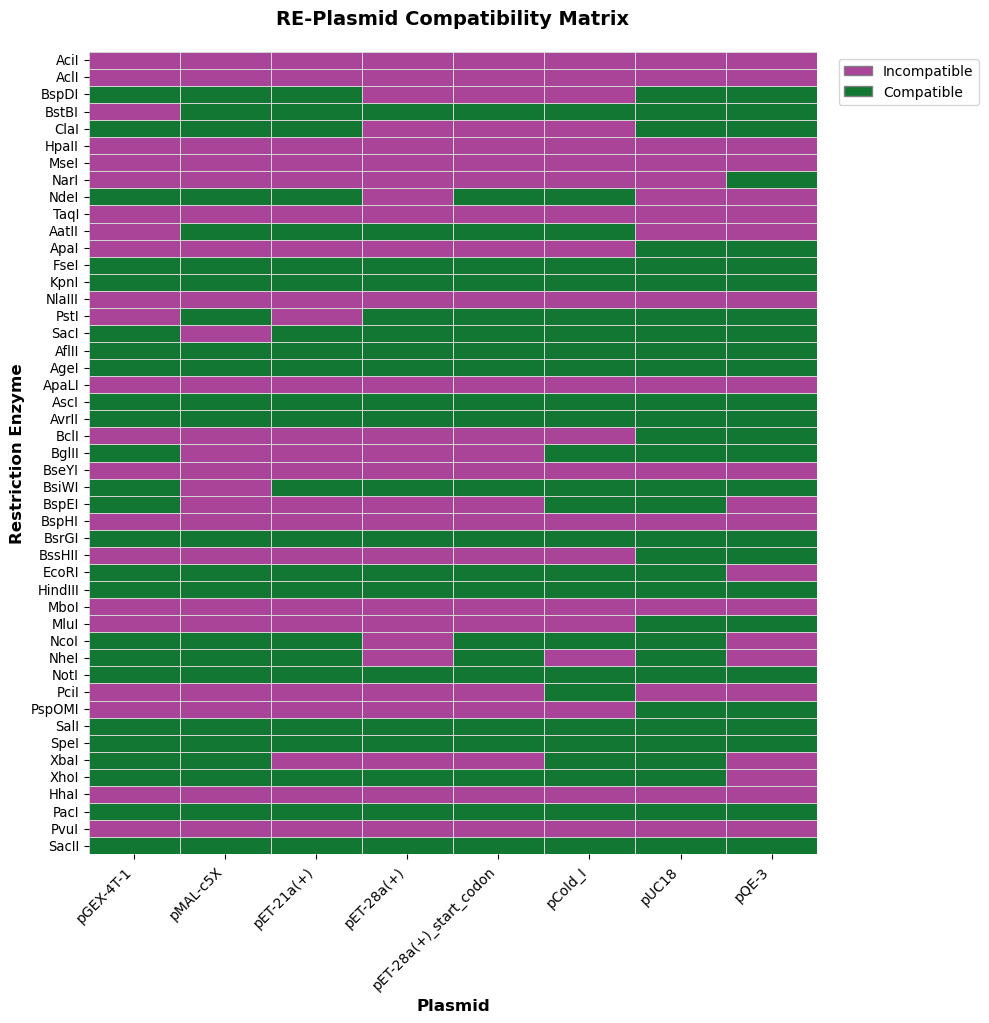


Heatmap dimensions: 47 enzymes × 8 plasmids


In [29]:
# Prepare data for heatmap
print("\nGenerating heatmap...")

# Sort enzymes: first by site (Site II first), then by ovhg, then alphabetically
df_re_plasmid_sorted = df_re_plasmid.sort_values(
    by=['site', 'ovhg', 'enzyme'], 
    ascending=[True, True, True]
)

# Extract compatibility matrix (convert True/False to 1/0)
heatmap_data = df_re_plasmid_sorted[plasmid_names].astype(int)
enzyme_labels = df_re_plasmid_sorted['enzyme'].tolist()
ovhg_labels = df_re_plasmid_sorted['ovhg'].tolist()

# Create enzyme labels without ovhg (just enzyme names)
enzyme_labels_simple = enzyme_labels

# Create figure with reduced height
fig, ax = plt.subplots(figsize=(10, len(enzyme_labels) * 0.22))

# Create heatmap with new colors
sns.heatmap(
    heatmap_data,
    cmap=['#AA4499', '#117733'],  # Purple for incompatible, green for compatible
    cbar=False,
    linewidths=0.5,
    linecolor='lightgray',
    square=False,
    ax=ax,
    yticklabels=enzyme_labels_simple,
    xticklabels=plasmid_names
)

# Set labels
ax.set_xlabel('Plasmid', fontsize=12, fontweight='bold')
ax.set_ylabel('Restriction Enzyme', fontsize=12, fontweight='bold')
ax.set_title('RE-Plasmid Compatibility Matrix', fontsize=14, fontweight='bold', pad=20)

# Rotate x-axis labels 45 degrees
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9.5)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#AA4499', edgecolor='gray', label='Incompatible'),
    Patch(facecolor='#117733', edgecolor='gray', label='Compatible')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), 
          frameon=True, fontsize=10)

# Tight layout
plt.tight_layout()

# Save figures
output_pdf = './output/re_plasmid_compatibility_heatmap.pdf'
output_png = './output/re_plasmid_compatibility_heatmap.png'

plt.savefig(output_pdf, dpi=300, bbox_inches='tight')
print(f"✓ Heatmap saved to: {output_pdf}")

plt.savefig(output_png, dpi=600, bbox_inches='tight')
print(f"✓ Heatmap saved to: {output_png}")

plt.show()

print(f"\nHeatmap dimensions: {len(enzyme_labels)} enzymes × {len(plasmid_names)} plasmids")

## Step 4.5: Generate Heatmap Visualization


Generating heatmap...
✓ Heatmap saved to: ./output/re_plasmid_compatibility_heatmap.pdf


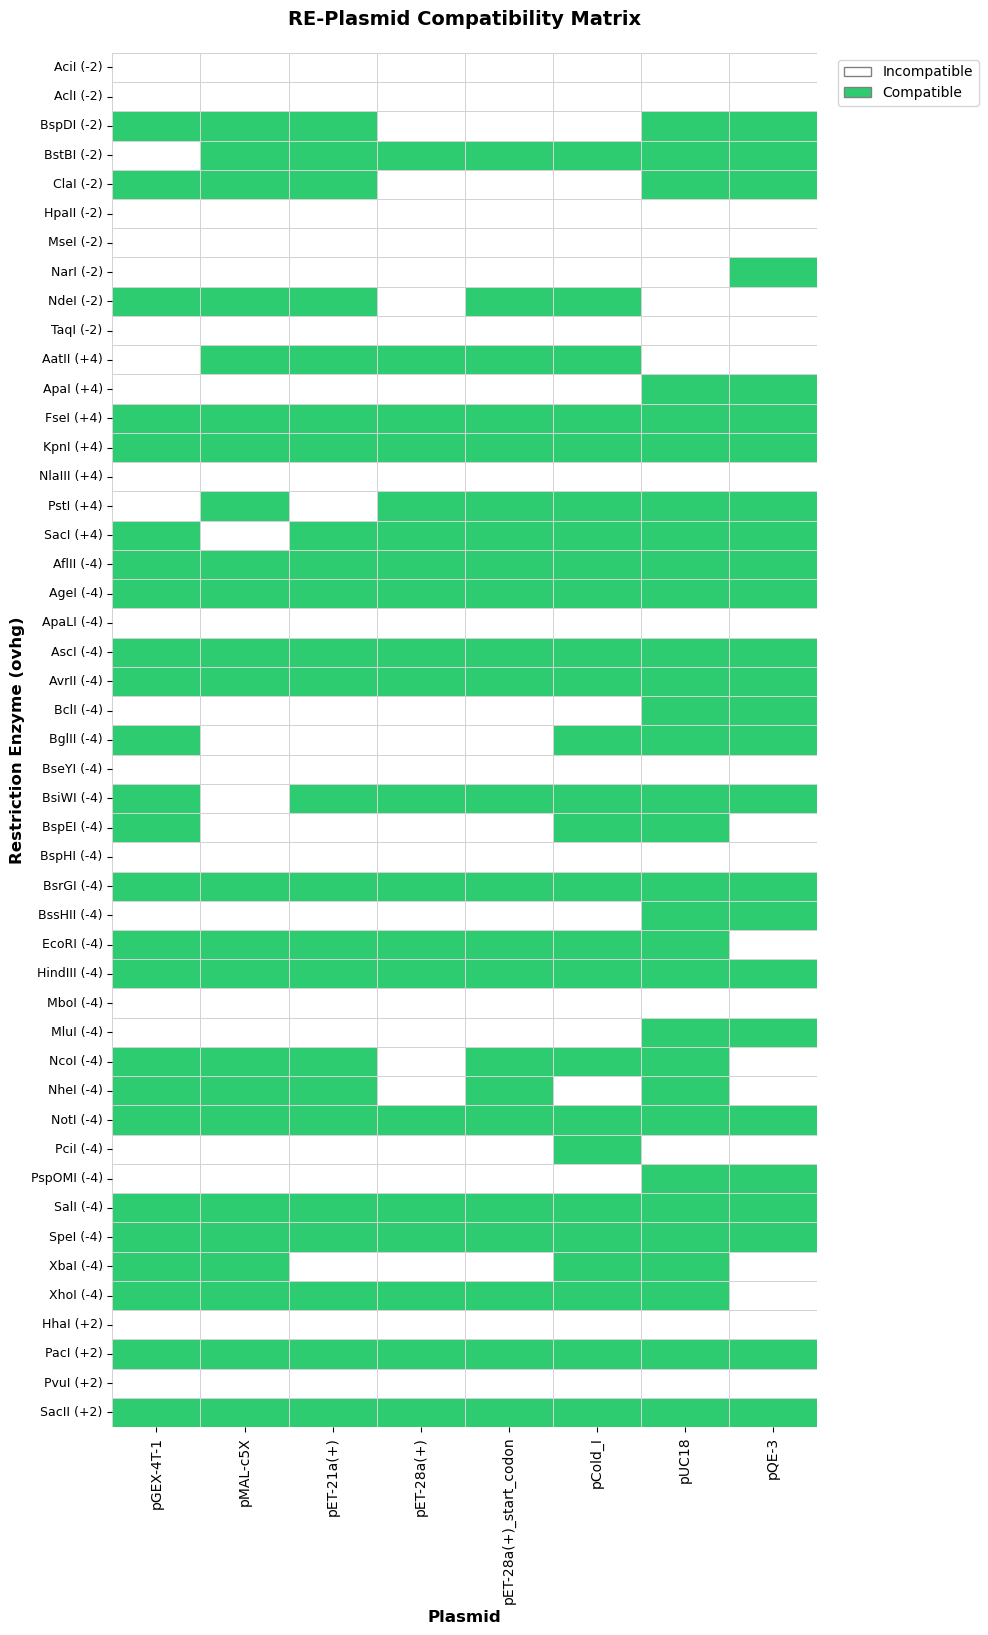


Heatmap dimensions: 47 enzymes × 8 plasmids


In [24]:
# Prepare data for heatmap
print("\nGenerating heatmap...")

# Sort enzymes: first by site (Site II first), then by ovhg, then alphabetically
df_re_plasmid_sorted = df_re_plasmid.sort_values(
    by=['site', 'ovhg', 'enzyme'], 
    ascending=[True, True, True]
)

# Extract compatibility matrix (convert True/False to 1/0)
heatmap_data = df_re_plasmid_sorted[plasmid_names].astype(int)
enzyme_labels = df_re_plasmid_sorted['enzyme'].tolist()
ovhg_labels = df_re_plasmid_sorted['ovhg'].tolist()

# Create enhanced enzyme labels with ovhg information
enzyme_labels_enhanced = [f"{enz} ({ovhg:+d})" for enz, ovhg in zip(enzyme_labels, ovhg_labels)]

# Create figure
fig, ax = plt.subplots(figsize=(10, len(enzyme_labels) * 0.35))

# Create heatmap
sns.heatmap(
    heatmap_data,
    cmap=['white', '#2ecc71'],  # White for incompatible, green for compatible
    cbar=False,
    linewidths=0.5,
    linecolor='lightgray',
    square=False,
    ax=ax,
    yticklabels=enzyme_labels_enhanced,
    xticklabels=plasmid_names
)

# Set labels
ax.set_xlabel('Plasmid', fontsize=12, fontweight='bold')
ax.set_ylabel('Restriction Enzyme (ovhg)', fontsize=12, fontweight='bold')
ax.set_title('RE-Plasmid Compatibility Matrix', fontsize=14, fontweight='bold', pad=20)

# Rotate x-axis labels vertically
plt.setp(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='white', edgecolor='gray', label='Incompatible'),
    Patch(facecolor='#2ecc71', edgecolor='gray', label='Compatible')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), 
          frameon=True, fontsize=10)

# Tight layout
plt.tight_layout()

# Save figure
output_fig = './output/re_plasmid_compatibility_heatmap.pdf'
plt.savefig(output_fig, dpi=300, bbox_inches='tight')
print(f"✓ Heatmap saved to: {output_fig}")

plt.show()

print(f"\nHeatmap dimensions: {len(enzyme_labels)} enzymes × {len(plasmid_names)} plasmids")

## Step 5: Export to CSV

In [25]:
# Export to CSV
output_file = './output/re_plasmid_compatibility.csv'
df_re_plasmid.to_csv(output_file, index=False)

print(f"✓ Saved to: {output_file}")
print(f"  Rows: {len(df_re_plasmid)}")
print(f"  Columns: {len(df_re_plasmid.columns)}")

# Also save a summary version (only enzymes compatible with at least one plasmid)
df_compatible = df_re_plasmid[df_re_plasmid[plasmid_names].any(axis=1)]
output_file_compatible = './output/re_plasmid_compatibility_filtered.csv'
df_compatible.to_csv(output_file_compatible, index=False)

print(f"\n✓ Saved filtered version (at least 1 plasmid compatible) to: {output_file_compatible}")
print(f"  Rows: {len(df_compatible)}")

print("\n" + "="*80)
print("✓ COMPLETE")
print("="*80)

✓ Saved to: ./output/re_plasmid_compatibility.csv
  Rows: 47
  Columns: 11

✓ Saved filtered version (at least 1 plasmid compatible) to: ./output/re_plasmid_compatibility_filtered.csv
  Rows: 35

✓ COMPLETE
